In [1]:
library(Seurat)
library(dplyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Cell ref

In [2]:
malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
malignant

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [3]:
rna <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/ascites_case/seurat_mnn-integration_malignant-cells_primary-tumor_AC-OPC_first-prettx.rds')
rna

An object of class Seurat 
25657 features across 2478 samples within 1 assay 
Active assay: RNA (25657 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: mnn, pca, umap

In [4]:
rna <- subset(rna, features=rownames(malignant))

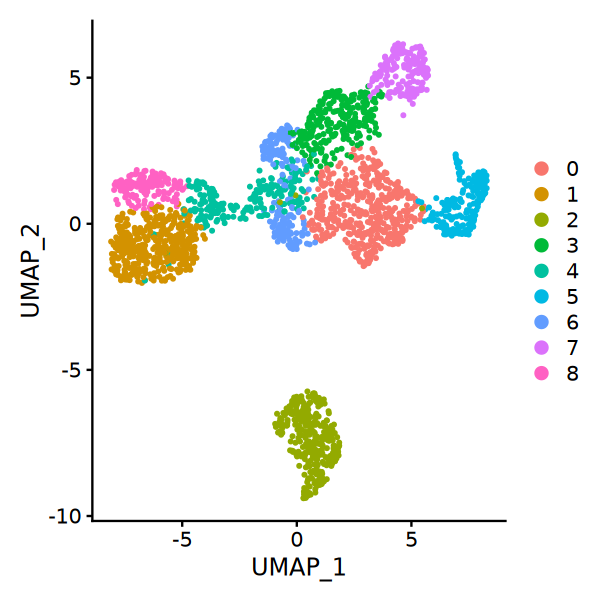

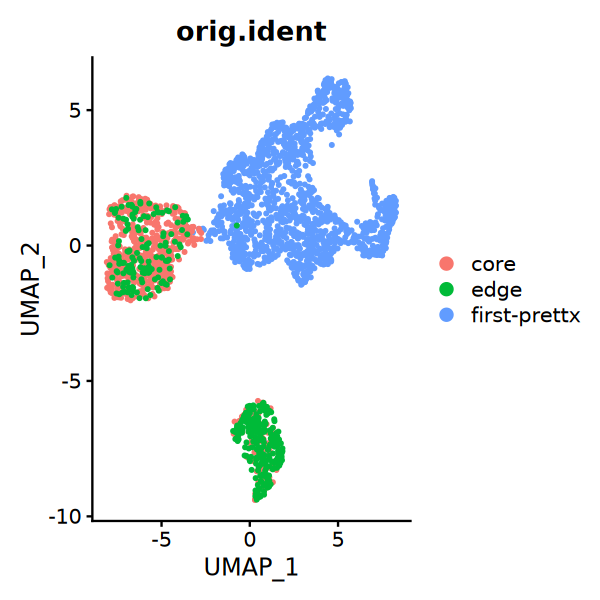

In [5]:
options(repr.plot.height = 5, repr.plot.width = 5)
DimPlot(rna)
DimPlot(rna, group.by = 'orig.ident')

In [6]:
rna$celltype <- dplyr::recode(rna$seurat_clusters,
                      '0'='RG-like',
                      '1'='AC-like',
                      '2'='OPC-like',
                      '3'='RG-like',
                      '4'='AC-like',
                      '5'='RG-like',
                      '6'='RG-like',
                      '7'='RG-like',
                      '8'='AC-like'
                      )

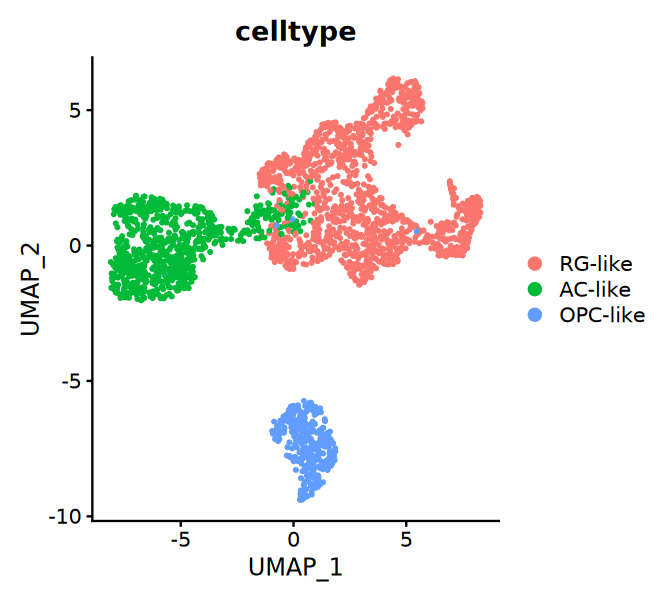

In [7]:
options(repr.plot.height = 5, repr.plot.width = 5.5)
DimPlot(rna, group.by = 'celltype')

In [9]:
ascites <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/ascites_case/seurat-mnn_integration_sct-norm_all-prettx_no-low-complex-cells.rds')
ascites

An object of class Seurat 
44017 features across 21704 samples within 2 assays 
Active assay: SCT (21525 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: mnn, umap

In [10]:
ascites <- UpdateSeuratObject(ascites)

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘mnn’

Updating matrix keys for DimReduc ‘umap’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in SCT

Updating slots in SCT_nn

Setting default assay of SCT_nn to SCT

Updating slots in SCT_snn

Setting default assay of SCT_snn to SCT

Updating slots in mnn

Updating slots in umap

Setting umap DimReduc to global

Setting assay used for RunFastMNN.SCT to SCT

Setting assay used for SCTransform.RNA to RNA

Setting assay used for RunUMAP.SCT.mnn to SCT

Setting assay used for FindNeighbors.SCT.mnn to SCT

No assay information could be found for FindClusters

Warning message:
“Adding a command log without an assay associated with it”
Validating object structure for Assay ‘RNA’

Validating object structure for SCTAssay ‘SCT’

Validating object structure for Graph ‘SCT_nn’


In [11]:
ascites <- subset(ascites, features=rownames(malignant))

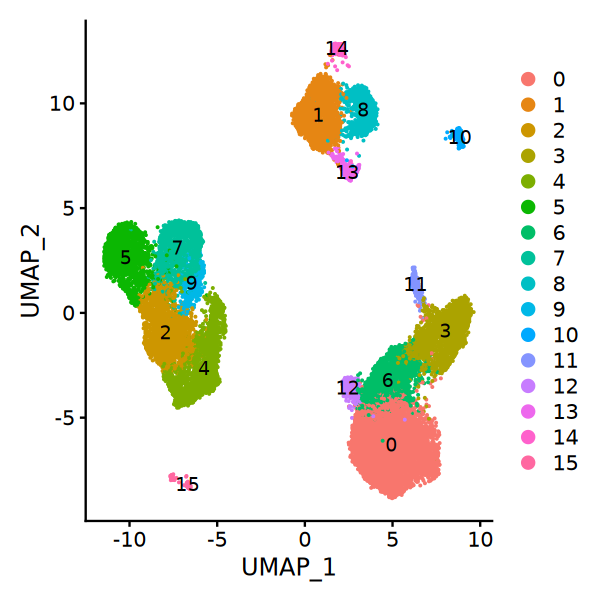

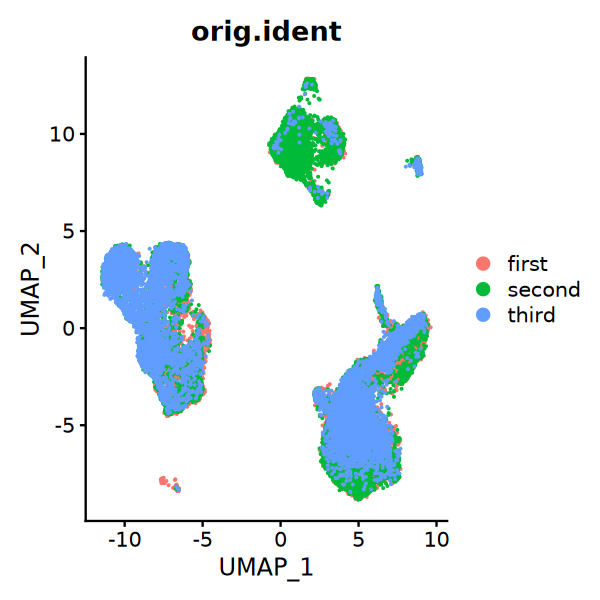

In [12]:
options(repr.plot.height = 5, repr.plot.width = 5)
DimPlot(ascites, label=TRUE)
DimPlot(ascites, group.by = 'orig.ident')

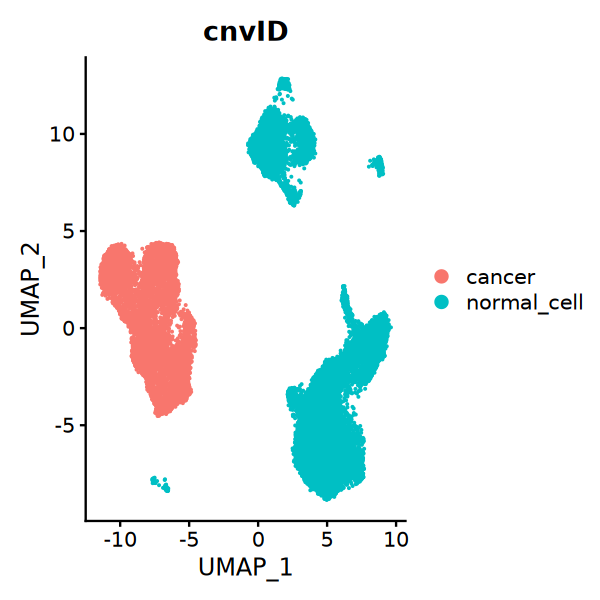

In [13]:
ascites$cnvID <- ifelse(
  ascites@active.ident %in% c("2", "4", "5", "7", "9"),
  "cancer",
  "normal_cell"
)
DimPlot(ascites, group.by = 'cnvID')

In [14]:
rna$status <- rna$celltype
ascites$status <- ascites$cnvID

In [16]:
ascites_normal <- subset(ascites, cnvID == 'normal_cell')
DefaultAssay(ascites_normal) <- 'RNA'

In [17]:
# Define the percentage of cells you want to subset (e.g., 30%)
subset_percentage <- 0.3

# Get the number of cells to subset
num_cells_subset <- round(nrow(ascites_normal) * subset_percentage)

# Randomly sample cell indices
subset_indices <- sample(1:nrow(ascites_normal), num_cells_subset, replace = FALSE)

# Use the subset function to subset the Seurat object
subset_ascites_normal <- subset(ascites_normal, cells = subset_indices)
subset_ascites_normal

An object of class Seurat 
32421 features across 4125 samples within 2 assays 
Active assay: RNA (16371 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: SCT
 2 dimensional reductions calculated: mnn, umap

In [18]:
subset_ascites_normal <- DietSeurat(subset_ascites_normal, assays = c("RNA"))
subset_ascites_normal

An object of class Seurat 
16371 features across 4125 samples within 1 assay 
Active assay: RNA (16371 features, 0 variable features)
 2 layers present: counts, data

In [19]:
all <- merge(rna, subset_ascites_normal, merge.data = FALSE)
all

An object of class Seurat 
17203 features across 6603 samples within 1 assay 
Active assay: RNA (17203 features, 0 variable features)
 2 layers present: counts, data

In [20]:
# writing tsv file for inferCNV  
write.table(as.matrix(GetAssayData(object = all, slot = "counts")), 
            'primary_ascites_cell_ref.tsv', sep = '\t', 
            row.names = T, col.names = T, quote = F)

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


In [21]:
Idents(all) <- all$status

In [22]:
library(data.table)
anno_file <- setDT(as.data.frame(Idents(all)), keep.rownames = TRUE)


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




In [23]:
write.table(anno_file, 'primary_ascites_cell_ref_meta.tsv', sep = '\t', 
            col.names = F, row.names = F, quote = F)

In [24]:
unique(all$status)

[1] "RG-like"     "AC-like"     "OPC-like"    "normal_cell"

### inferCNV analysis

In [1]:
library(infercnv)
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.4 (Plow)

Matrix products: default
BLAS/LAPACK: /gpfs/home3/cruiz2/miniconda3/envs/r_env_standr/lib/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Amsterdam
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] infercnv_1.18.1

loaded via a namespace (and not attached):
  [1] RcppAnnoy_0.0.22            splines_4.3.2              
  [3] later_1.3.2                 pbdZMQ_0.3-11              
  [5

In [2]:
# create the infercnv object
infercnv_obj = CreateInfercnvObject(raw_counts_matrix='primary_ascites_cell_ref.tsv',
                                    annotations_file='primary_ascites_cell_ref_meta.tsv',
                                    delim="\t",
                                    gene_order_file="gencode_v38_gene_pos.txt",
                                    ref_group_names=c('normal_cell')
                                    )

INFO [2024-12-20 05:16:41] Parsing matrix: primary_ascites_cell_ref.tsv
INFO [2024-12-20 05:17:11] Parsing gene order file: gencode_v38_gene_pos.txt
INFO [2024-12-20 05:17:11] Parsing cell annotations file: primary_ascites_cell_ref_meta.tsv
INFO [2024-12-20 05:17:11] ::order_reduce:Start.
INFO [2024-12-20 05:17:11] .order_reduce(): expr and order match.
INFO [2024-12-20 05:17:12] ::process_data:order_reduce:Reduction from positional data, new dimensions (r,c) = 17203,6603 Total=95649240 Min=0 Max=4083.
INFO [2024-12-20 05:17:12] num genes removed taking into account provided gene ordering list: 635 = 3.69121664825902% removed.
INFO [2024-12-20 05:17:13] -filtering out cells < 100 or > Inf, removing 0 % of cells
WARN [2024-12-20 05:17:13] Please use "options(scipen = 100)" before running infercnv if you are using the analysis_mode="subclusters" option or you may encounter an error while the hclust is being generated.
INFO [2024-12-20 05:17:15] validating infercnv_obj


In [3]:
# perform infercnv operations to reveal cnv signal
infercnv_obj = infercnv::run(infercnv_obj,
                             cutoff=0.1,  # use 1 for smart-seq, 0.1 for 10x-genomics
                             out_dir="output_inferCNV_primary_ascites_ref_cell",  # dir is auto-created for storing outputs
                             cluster_by_groups=F,   # cluster
                             denoise=T,
                             HMM=T,
                             analysis_mode='subclusters',
                             HMM_type='i6',
                             num_threads = 48,
                             # tumor_subcluster_partition_method='random_trees',
                             write_phylo=TRUE
                             )

INFO [2024-12-20 05:18:01] ::process_data:Start
INFO [2024-12-20 05:18:01] Creating output path output_inferCNV_primary_ascites_ref_cell
INFO [2024-12-20 05:18:01] Checking for saved results.
INFO [2024-12-20 05:18:01] 

	STEP 1: incoming data

INFO [2024-12-20 05:18:23] 

	STEP 02: Removing lowly expressed genes

INFO [2024-12-20 05:18:23] ::above_min_mean_expr_cutoff:Start
INFO [2024-12-20 05:18:24] Removing 181 genes from matrix as below mean expr threshold: 0.1
INFO [2024-12-20 05:18:25] validating infercnv_obj
INFO [2024-12-20 05:18:25] There are 16387 genes and 6603 cells remaining in the expr matrix.
INFO [2024-12-20 05:18:28] no genes removed due to min cells/gene filter
INFO [2024-12-20 05:18:50] 

	STEP 03: normalization by sequencing depth

INFO [2024-12-20 05:18:50] normalizing counts matrix by depth
INFO [2024-12-20 05:18:52] Computed total sum normalization factor as median libsize: 4969.000000
INFO [2024-12-20 05:18:53] Adding h-spike
INFO [2024-12-20 05:18:53] -hspike m

Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  PANK1, SLC16A12, IFIT5, IFIT1, KIF20B, IFIT1B, IFIT3, HTR7, IFIT2, LIPA 
	   RPP30, CH25H, PCGF5, FAS, HECTD2, ACTA2, PPP1R3C, STAMBPL1, TNKS2, ANKRD22 
	   FGFBP3, LIPN, MAPK8, FRMPD2, ARHGAP22, WDFY4, BTAF1, LIPK, LRRC18, VSTM4 
Negative:  NABP2, SLC39A5, ANKRD52, COQ10A, CS, CNPY2, PAN2, IL23A, STAT2, APOF 
	   TIMELESS, MIP, SPRYD4, GLS2, RBMS2, GTSF1, BAZ2A, ATP5F1B, PTGES3, CBX5 
	   SMUG1, NACA, HOXC4, HOXC8, PRIM1, HOXC9, HOXC6, HSD17B6, HOXC10, CALCOCO1 
PC_ 2 
Positive:  RIPPLY3, PIGP, HLCS, TTC3, SIM2, VPS26C, CLDN14, DYRK1A, CHAF1B, KCNJ6 
	   MORC3, CBR3, CBR1, SETD4, RUNX1, EVA1C, URB1, TCP10L, MRAP, CFAP298 
	   SYNJ1, MIS18A, CLIC6, PAXBP1, HUNK, C21orf62, RCAN1, SCAF4, OLIG2, OLIG1 
Negative:  KCTD17, MPST, TST, TEX33, CSF2RB, NCF4, PVALB, IFT27, CACNG2, EIF3D 
	   FOXRED2, TXN2, MYH9, APOL1, APOL2, APOL4, S

INFO [2024-12-20 05:32:36] define_signif_tumor_subclusters(), tumor: normal_cell
INFO [2024-12-20 05:32:36] Setting auto leiden resolution for normal_cell to 0.00664272


Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  LIPA, IFIT2, IFIT3, IFIT1B, IFIT1, IFIT5, CH25H, SLC16A12, PANK1, KIF20B 
	   HTR7, FAS, RPP30, PCGF5, HECTD2, ACTA2, PPP1R3C, TNKS2, FGFBP3, STAMBPL1 
	   BTAF1, CPEB3, ANKRD22, LIPN, LIPK, RNLS, PCDHB5, ERICH1, PCDHB6, TDRP 
Negative:  IL32, ZNF205, ZNF213, MMP25, ZNF200, MEFV, ZNF263, TIGD7, BICDL2, ZNF75A 
	   MTRNR2L4, ZSCAN32, AC025283.2, THOC6, ZNF174, ZNF597, HCFC1R1, NAA60, TNFRSF12A, CLUAP1 
	   CLDN6, NLRC3, SLX4, CLDN9, NLRX1, DNASE1, PAQR4, PDZD3, TRAP1, PKMYT1 
PC_ 2 
Positive:  SPSB3, NUBP2, EME2, MRPS34, HAGH, NME3, FAHD1, MAPK8IP3, MEIOB, HS3ST6 
	   JPT2, MSRB1, CRAMP1, RPL3L, TMEM204, NDUFB10, IFT140, RPS2, TELO2, TBL3 
	   NOXO1, CLCN7, CCDC154, GFER, C16orf91, UNKL, GNPTG, SYNGR3, TSR3, ZNF598 
Negative:  FDCSP, SMR3B, ODAM, MUC7, PRR27, AMTN, HTN1, AMBN, SULT1B1, UGT2B4 
	   ENAM, UGT2B7, JCHAIN, UGT2B1

INFO [2024-12-20 05:32:55] -mirroring for hspike
INFO [2024-12-20 05:32:55] define_signif_tumor_subclusters(p_val=0.1
INFO [2024-12-20 05:32:55] define_signif_tumor_subclusters(), tumor: spike_tumor_cell_normal_cell
INFO [2024-12-20 05:32:55] cut tree into: 1 groups
INFO [2024-12-20 05:32:55] -processing spike_tumor_cell_normal_cell,spike_tumor_cell_normal_cell_s1
INFO [2024-12-20 05:32:55] define_signif_tumor_subclusters(), tumor: simnorm_cell_normal_cell
INFO [2024-12-20 05:32:55] cut tree into: 1 groups
INFO [2024-12-20 05:32:55] -processing simnorm_cell_normal_cell,simnorm_cell_normal_cell_s1
INFO [2024-12-20 05:34:34] ::plot_cnv:Start
INFO [2024-12-20 05:34:34] ::plot_cnv:Current data dimensions (r,c)=16387,6603 Total=108067206.928906 Min=0.140935866091154 Max=6.34187392003713.
INFO [2024-12-20 05:34:37] ::plot_cnv:Depending on the size of the matrix this may take a moment.
INFO [2024-12-20 05:34:40] plot_cnv(): auto thresholding at: (0.910094 , 1.087389)
INFO [2024-12-20 05:34:45